## Loading dataset

#### Import necessary libraries and download the dataset.

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.feature_selection import mutual_info_classif

path = kagglehub.dataset_download("vicsuperman/prediction-of-music-genre")
print("Path to dataset files:", path)

# List files in the downloaded dataset
files = os.listdir(path)
print("Dataset files:", files)

df = pd.read_csv(os.path.join(path, "music_genre.csv"))
df.head()

/Users/scottwu/Documents/Code/AcademicProjects/Intro_to_ML_A02/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/scottwu/.cache/kagglehub/datasets/vicsuperman/prediction-of-music-genre/versions/1
Dataset files: ['music_genre.csv']


,instance_id,artist_name,track_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,obtained_date,valence,music_genre
0,32894.0,Röyksopp,Röyksopp's Night Out,27.0,0.00468,0.652,-1.0,0.941,0.79200,A#,0.115,-5.201,Minor,0.0748,100.889,4-Apr,0.759,Electronic
1,46652.0,Thievery Corporation,The Shining Path,31.0,0.01270,0.622,218293.0,0.890,0.95000,D,0.124,-7.043,Minor,0.0300,115.00200000000001,4-Apr,0.531,Electronic
2,30097.0,Dillon Francis,Hurricane,28.0,0.00306,0.620,215613.0,0.755,0.01180,G#,0.534,-4.617,Major,0.0345,127.994,4-Apr,0.333,Electronic
3,62177.0,Dubloadz,Nitro,34.0,0.02540,0.774,166875.0,0.700,0.00253,C#,0.157,-4.498,Major,0.2390,128.014,4-Apr,0.270,Electronic
4,24907.0,What So Not,Divide & Conquer,32.0,0.00465,0.638,222369.0,0.587,0.90900,F#,0.157,-6.266,Major,0.0413,145.036,4-Apr,0.323,Electronic


## Data Cleaning and Encoding

#### Cleaning the below:
- Cleanup the rows with "?", -1, and then convert the columns to float type.
- Remove duplicated tracks.
- Remove outliers in 'duration_ms' with the lonest 1% of the data.
- Drop unrelated columns.

In [2]:
df["tempo"] = df["tempo"].replace("?", np.nan)
df = df.dropna(subset=["tempo"])
df["tempo"] = df["tempo"].astype(float)

df["key"] = df["key"].replace("?", np.nan)
df = df.dropna(subset=["key"])

df["duration_ms"] = df["duration_ms"].replace(-1.0, np.nan)
df = df.dropna(subset=["duration_ms"])
df["duration_ms"] = df["duration_ms"].astype(float)

print(f"Number of rows before dropping duplicates: {len(df)}")
df = df.drop_duplicates(subset=["artist_name", "track_name", "instance_id"])
print(f"Number of rows after dropping duplicates: {len(df)}")

duration_threshold = df["duration_ms"].quantile(0.99)
df = df[df["duration_ms"] <= duration_threshold]

df = df.drop(columns=["artist_name", "track_name", "instance_id", "obtained_date"])

Number of rows before dropping duplicates: 40560
Number of rows after dropping duplicates: 40560


#### Data encoding and feature combinition
- 'mode' is the target column but it is not numerical. `LabelEncoder` sorts labels alphabetically, so it maps Major = 0, Minor = 1.
- Musical mode is highly related to the emotions, it is helpful for predictions to combine emotion-related variables to create new variables.
- 'key' in musical are ordered in sequence and has a cyclical nature, therefore, they can be encoded cyclically to represent this nature.

In [3]:
label_encoder = LabelEncoder()
df["mode"] = label_encoder.fit_transform(df["mode"])

df["energy_danceability"] = df["energy"] * df["danceability"]
df["valence_danceability"] = df["valence"] * df["danceability"]
df["energy_valence"] = df["energy"] * df["valence"]

df["key"] = label_encoder.fit_transform(df["key"])
df["key_sin"] = np.sin(2 * np.pi * df["key"] / 12)
df["key_cos"] = np.cos(2 * np.pi * df["key"] / 12)
df = df.drop(columns=["key"])

# Ensure a continuous index after row filtering so later assignments align by row position.
df = df.reset_index(drop=True)
df.head()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,mode,speechiness,tempo,valence,music_genre,energy_danceability,valence_danceability,energy_valence,key_sin,key_cos
0,31.0,0.01270,0.622,218293.0,0.890,0.950000,0.124,-7.043,1,0.0300,115.002,0.531,Electronic,0.553580,0.330282,0.472590,0.500000,-8.660254e-01
1,28.0,0.00306,0.620,215613.0,0.755,0.011800,0.534,-4.617,0,0.0345,127.994,0.333,Electronic,0.468100,0.206460,0.251415,-0.500000,8.660254e-01
2,34.0,0.02540,0.774,166875.0,0.700,0.002530,0.157,-4.498,0,0.2390,128.014,0.270,Electronic,0.541800,0.208980,0.189000,0.866025,-5.000000e-01
3,32.0,0.00465,0.638,222369.0,0.587,0.909000,0.157,-6.266,0,0.0413,145.036,0.323,Electronic,0.374506,0.206074,0.189601,-1.000000,-1.836970e-16
4,46.0,0.02890,0.572,214408.0,0.803,0.000008,0.106,-4.294,0,0.3510,149.995,0.230,Electronic,0.459316,0.131560,0.184690,0.866025,5.000000e-01


## Data Visualisation

#### Class distribution: Major vs Minor

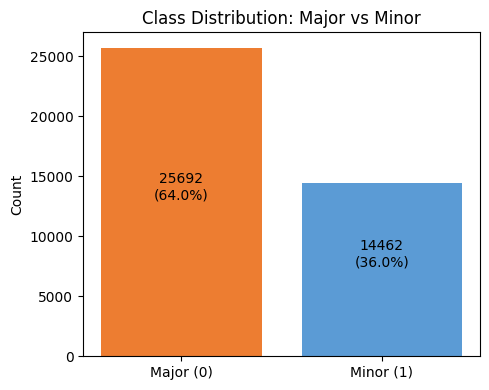

In [4]:
# LabelEncoder maps alphabetically: Major=0, Minor=1
mode_counts = df["mode"].value_counts().sort_index()
labels = ["Major (0)", "Minor (1)"]
colors = ["#ED7D31", "#5B9BD5"]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels, mode_counts.values, color=colors)
ax.set_title("Class Distribution: Major vs Minor")
ax.set_ylabel("Count")
for bar, count in zip(bars, mode_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_center()[1],
        f"{count}\n({count / len(df) * 100:.1f}%)",
        ha="center", va="bottom"
    )
plt.tight_layout()
plt.show()

#### Box plots of each continuous feature grouped by mode

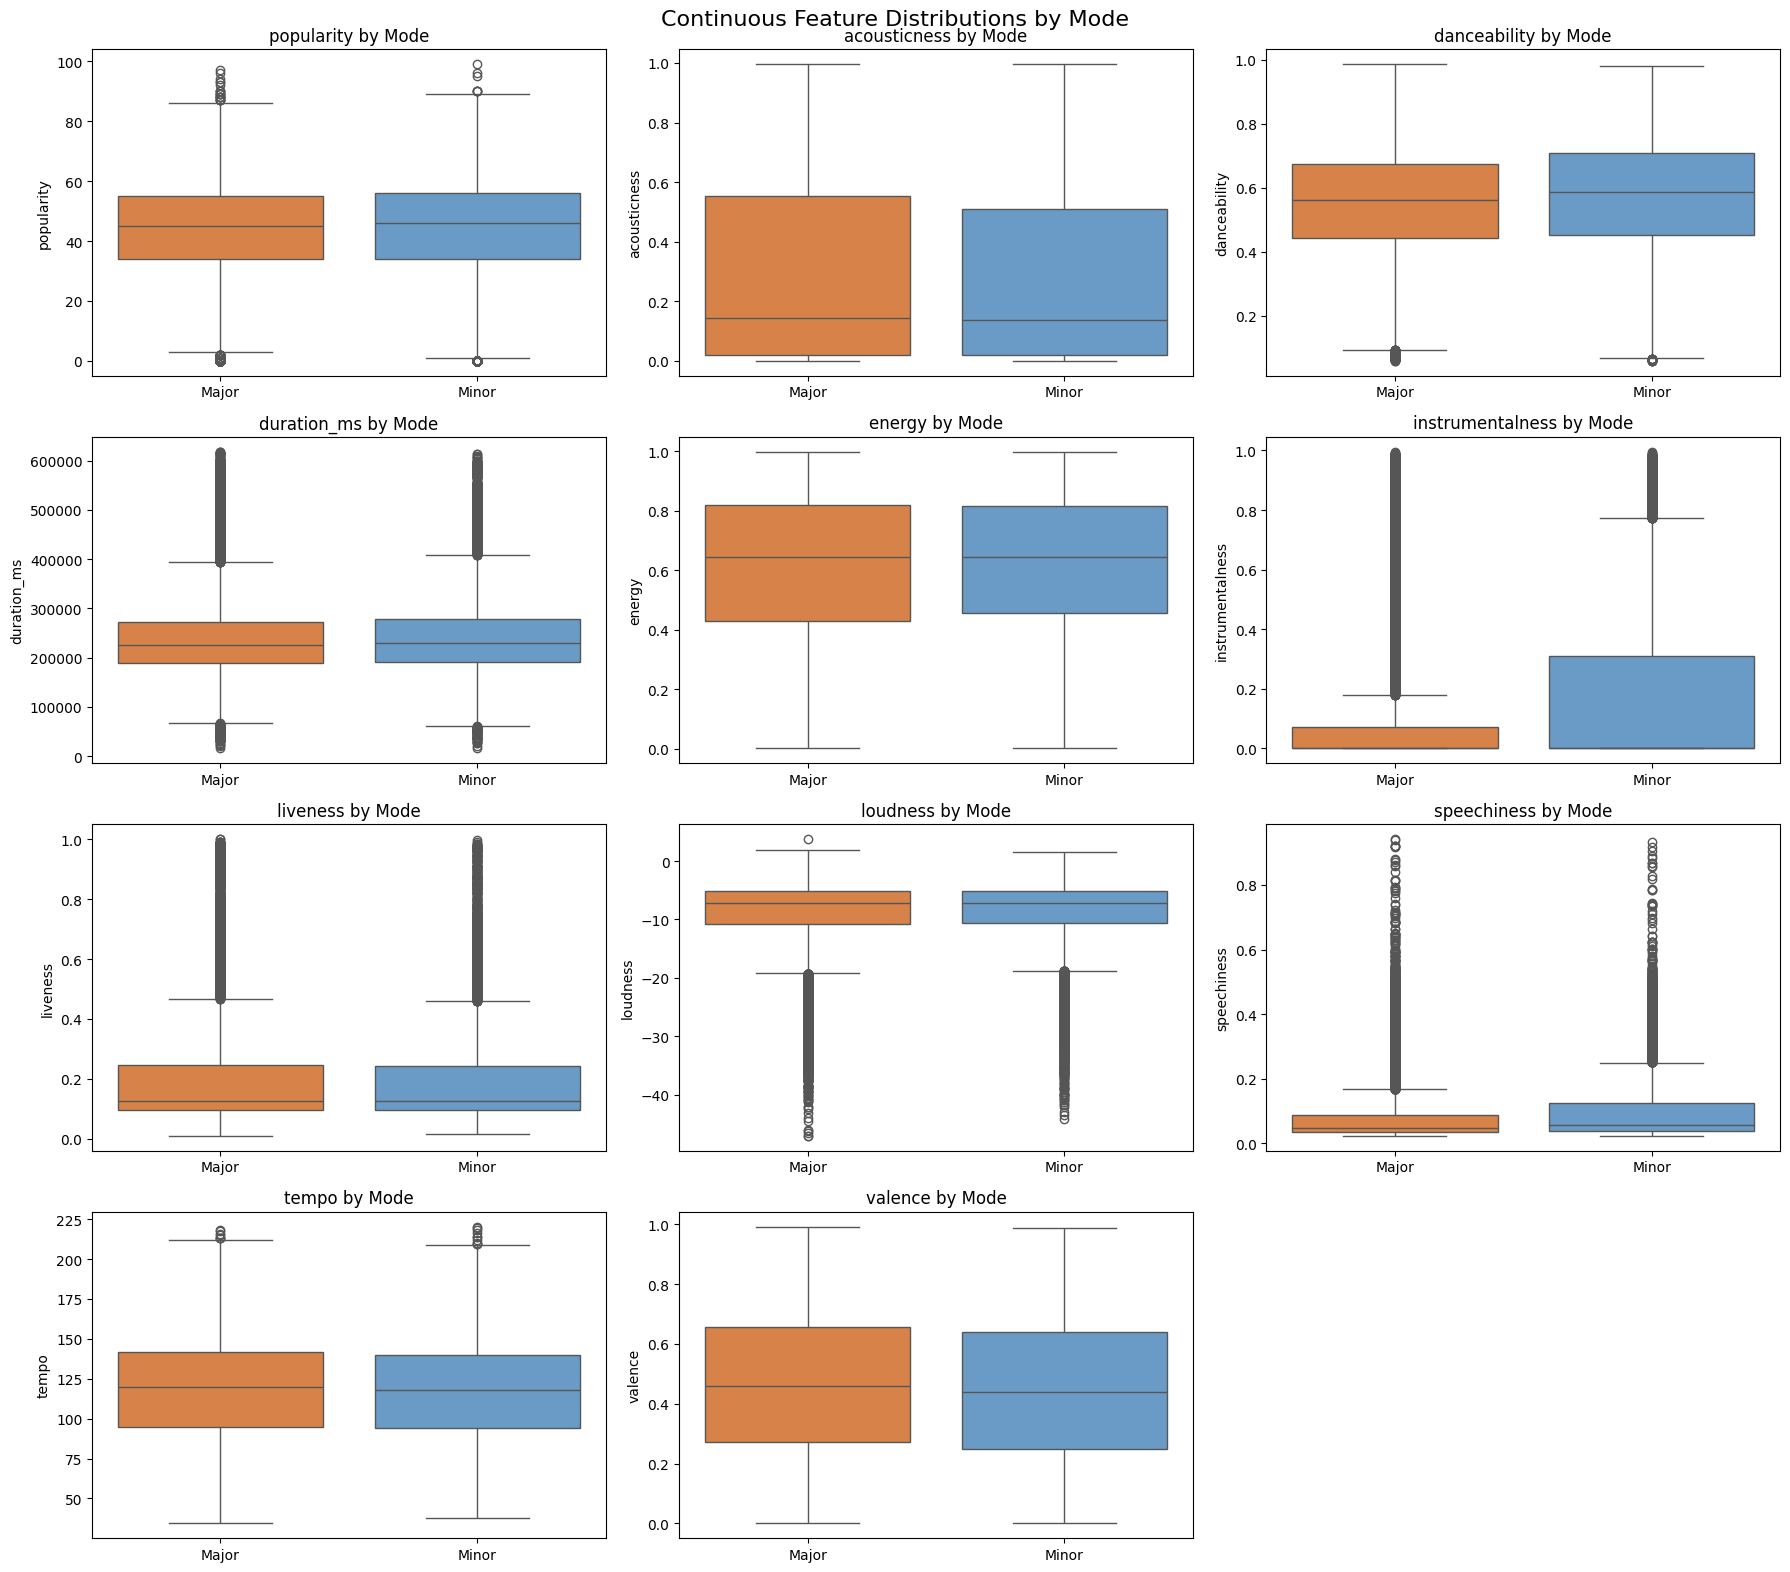

In [5]:
continuous_features = [
    "popularity", "acousticness", "danceability", "duration_ms",
    "energy", "instrumentalness", "liveness", "loudness",
    "speechiness", "tempo", "valence"
]

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    sns.boxplot(
        data=df, x="mode", y=feature, ax=axes[i],
        palette=["#ED7D31", "#5B9BD5"], hue="mode", legend=False
    )
    axes[i].set_title(f"{feature} by Mode")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Major", "Minor"])
    axes[i].set_xlabel("")

fig.delaxes(axes[11])
plt.suptitle("Continuous Feature Distributions by Mode", fontsize=16)
plt.tight_layout()
plt.show()

#### Major/Minor counts per genre

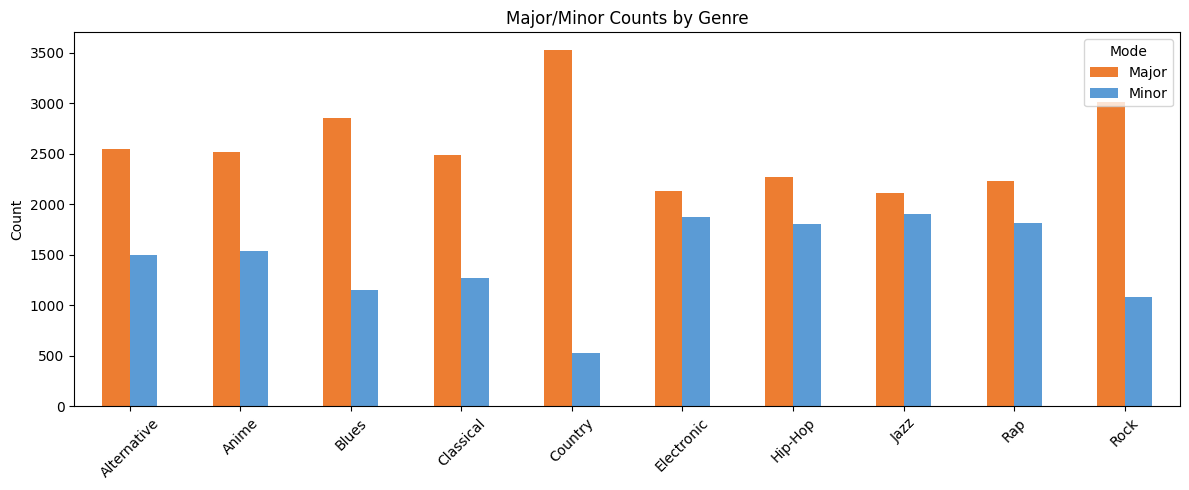

In [6]:
genre_mode = df.groupby(["music_genre", "mode"]).size().unstack(fill_value=0)
genre_mode.columns = ["Major", "Minor"]
genre_mode_pct = genre_mode.div(genre_mode.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
genre_mode.plot(kind="bar", ax=ax, color=["#ED7D31", "#5B9BD5"])
ax.set_title("Major/Minor Counts by Genre")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Mode", loc="upper right")
plt.tight_layout()
plt.show()

#### Major/Minor counts per key

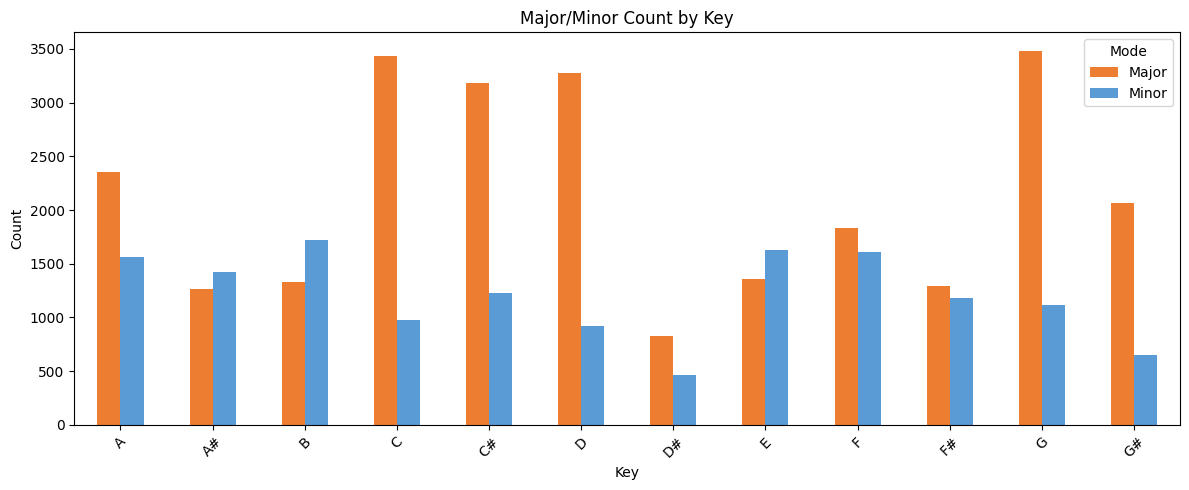

In [7]:
# Recover key names from cyclical encoding
# key_int = round(arctan2(sin, cos) * 12 / 2π) % 12 reverses the sin/cos transform
key_names = ['A', 'A#', 'B', 'C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#']
key_int = np.round(np.arctan2(df["key_sin"], df["key_cos"]) * 12 / (2 * np.pi)).astype(int) % 12
df_vis = df.copy()
df_vis["key_name"] = key_int.map(dict(enumerate(key_names)))

key_mode = df_vis.groupby(["key_name", "mode"]).size().unstack(fill_value=0)
key_mode.columns = ["Major", "Minor"]
key_mode = key_mode.reindex(key_names)  # order keys musically (A through G#)
key_mode_pct = key_mode.div(key_mode.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 5))

key_mode.plot(kind="bar", ax=ax, color=["#ED7D31", "#5B9BD5"])
ax.set_title("Major/Minor Count by Key")
ax.set_xlabel("Key")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Mode")

plt.tight_layout()
plt.show()

#### Correlation heatmap of all numeric features after encoding

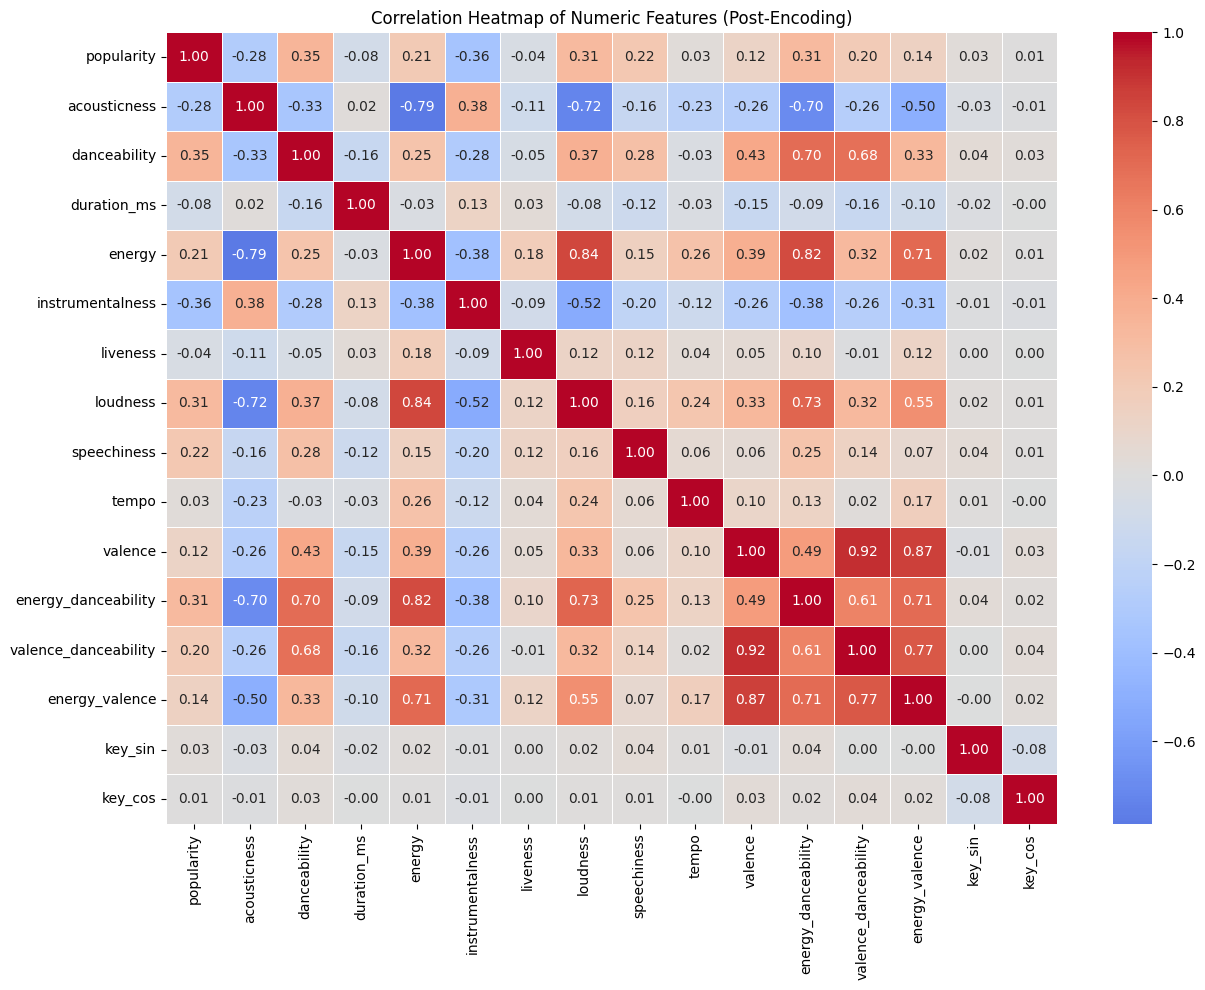

In [8]:
numeric_cols = df.select_dtypes(include="number").drop(columns=["mode"]).columns

plt.figure(figsize=(13, 10))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True, cmap="coolwarm", fmt=".2f", center=0, linewidths=0.5
)
plt.title("Correlation Heatmap of Numeric Features (Post-Encoding)")
plt.tight_layout()
plt.show()

## Data Stratification
#### Stratify with 70% train and 30% test to maintain class balance

In [9]:
X = df.drop(columns=["mode"])
y = df["mode"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## Feature Selection
#### Compute mutual information against `mode`, it measures how much knowing a feature reduces uncertainty about `mode`. 

                Feature  MI Score
                    key  0.037590
   valence_danceability  0.018638
                  tempo  0.017939
            duration_ms  0.016601
    energy_danceability  0.015453
    music_genre_Country  0.015392
            speechiness  0.014152
         energy_valence  0.012435
               loudness  0.008803
       instrumentalness  0.007094
           acousticness  0.006013
           danceability  0.005999
               liveness  0.005202
       music_genre_Jazz  0.003264
 music_genre_Electronic  0.002808
       music_genre_Rock  0.002210
        music_genre_Rap  0.001742
    music_genre_Hip-Hop  0.001704
      music_genre_Blues  0.001260
                 energy  0.001112
                valence  0.000563
  music_genre_Classical  0.000088
music_genre_Alternative  0.000034
      music_genre_Anime  0.000024
             popularity  0.000000


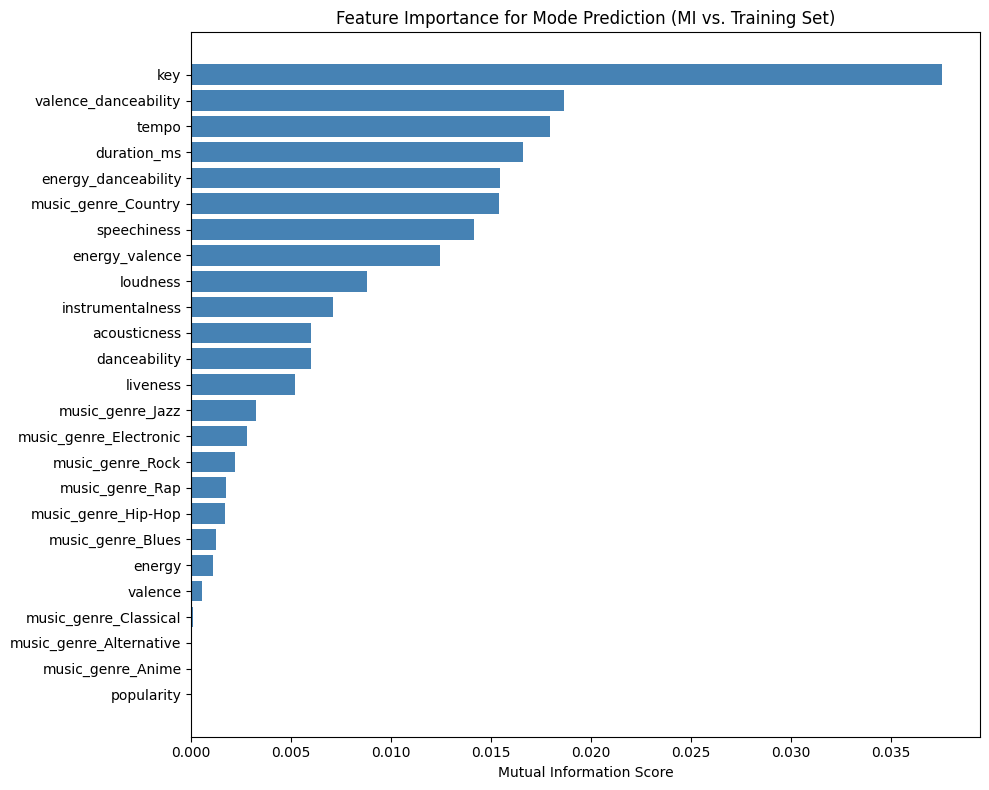

In [10]:
# One-hot encode music_genre on train and test separately, then align columns
X_train_enc = pd.get_dummies(X_train, columns=["music_genre"])
X_test_enc = pd.get_dummies(X_test, columns=["music_genre"])

# For MI, key_sin and key_cos are recombined into a single discrete key integer,
# since together they encode one circular variable — computing MI on each separately
# gives two partial scores rather than one accurate measure of key's predictive value.
key_int_train = (
    np.round(np.arctan2(X_train_enc["key_sin"], X_train_enc["key_cos"]) * 12 / (2 * np.pi))
    .astype(int) % 12
)
X_mi = X_train_enc.drop(columns=["key_sin", "key_cos"]).copy()
X_mi["key"] = key_int_train

# Mark discrete features: one-hot genre columns and the recovered key integer
discrete_mask = [c.startswith("music_genre_") or c == "key" for c in X_mi.columns]

mi_scores = mutual_info_classif(X_mi, y_train, discrete_features=discrete_mask, random_state=42)
mi_df = pd.DataFrame({"Feature": X_mi.columns, "MI Score": mi_scores})
mi_df = mi_df.sort_values("MI Score", ascending=False).reset_index(drop=True)

print(mi_df.to_string(index=False))

plt.figure(figsize=(10, 8))
plt.barh(mi_df["Feature"][::-1], mi_df["MI Score"][::-1], color="steelblue")
plt.xlabel("Mutual Information Score")
plt.title("Feature Importance for Mode Prediction (MI vs. Training Set)")
plt.tight_layout()
plt.show()

## Feature Scaling

#### The selected models (SVM, Logistic Regression, Neural Network) are all sensitive to feature scale, so `StandardScaler` is applied.

- Fit only on `X_train`, then transform `X_test` — prevents test statistics from leaking into training.
- `key_sin`/`key_cos` are already in [−1, 1] and are not scaled.
- One-hot encoded `music_genre` columns are 0 and 1, so not scaled.

In [11]:
# Align ensures test has the same columns as train
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join="left", axis=1, fill_value=0)

no_scale_cols = [c for c in X_train_enc.columns
                 if c.startswith("music_genre_") or c in ["key_sin", "key_cos"]]
scale_cols = [c for c in X_train_enc.columns if c not in no_scale_cols]

# Fit scaler on X_train only, then transform both sets
scaler = StandardScaler()
X_train_scaled = X_train_enc.copy()
X_test_scaled = X_test_enc.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train_enc[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test_enc[scale_cols])

print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")
X_train_scaled.head()

X_train_scaled: (28107, 26)
X_test_scaled:  (12047, 26)


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,...,music_genre_Alternative,music_genre_Anime,music_genre_Blues,music_genre_Classical,music_genre_Country,music_genre_Electronic,music_genre_Hip-Hop,music_genre_Jazz,music_genre_Rap,music_genre_Rock
37908,0.745247,-0.869204,0.469038,-1.098043,-0.479042,-0.548996,0.556746,0.394573,0.859312,-1.303727,...,False,False,False,False,False,False,True,False,False,False
29633,0.680723,-0.887664,-0.670252,-0.428009,1.296815,-0.536941,-0.527869,0.782545,-0.408293,1.201193,...,False,False,False,False,False,False,False,False,False,True
28600,0.680723,-0.531395,0.249076,-0.675040,1.055696,-0.548996,0.519559,0.835059,-0.562951,0.325586,...,False,False,False,False,False,False,False,False,False,True
21430,1.455014,-0.808030,0.925882,0.008565,0.133323,-0.548996,-0.589847,0.181537,2.327581,1.499343,...,False,False,False,False,False,False,False,False,True,False
14304,0.229052,1.454326,0.435198,-0.165944,-1.497097,-0.545931,-0.292353,-0.825500,-0.636364,-1.268029,...,True,False,False,False,False,False,False,False,False,False


## Data Modeling without Feature Selection

## Data Modeling with Feature Selection